#  [LAB 07] 추론통계 - 10. 상관분석의 가정 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import * 
from pandas import DataFrame

import numpy as np
import statsmodels.api as sm 
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import pearsonr, spearmanr

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 

In [2]:
origin = load_data('language_math_scores')
origin.head()

📚 어느 학급의 언어영역과 수리영역 점수를 기록한 가상의 데이터 셋


,언어영역,수리영역
0,66,66
1,58,70
2,73,74
3,52,58
4,72,79


## #02. 상관분석의 가정 확인 

### 1. 정규성 

In [3]:
report = my_stats.test_assumptions(origin, columns=["언어영역", "수리영역"])
norm_x = bool(report.loc["언어영역", "result"])
norm_y = bool(report.loc["수리영역", "result"])
print(f"정규성 -> 언어영역 : {norm_x}, 수리영역: {norm_y}")

정규성 -> 언어영역 : True, 수리영역: True


### 2. 선형성 

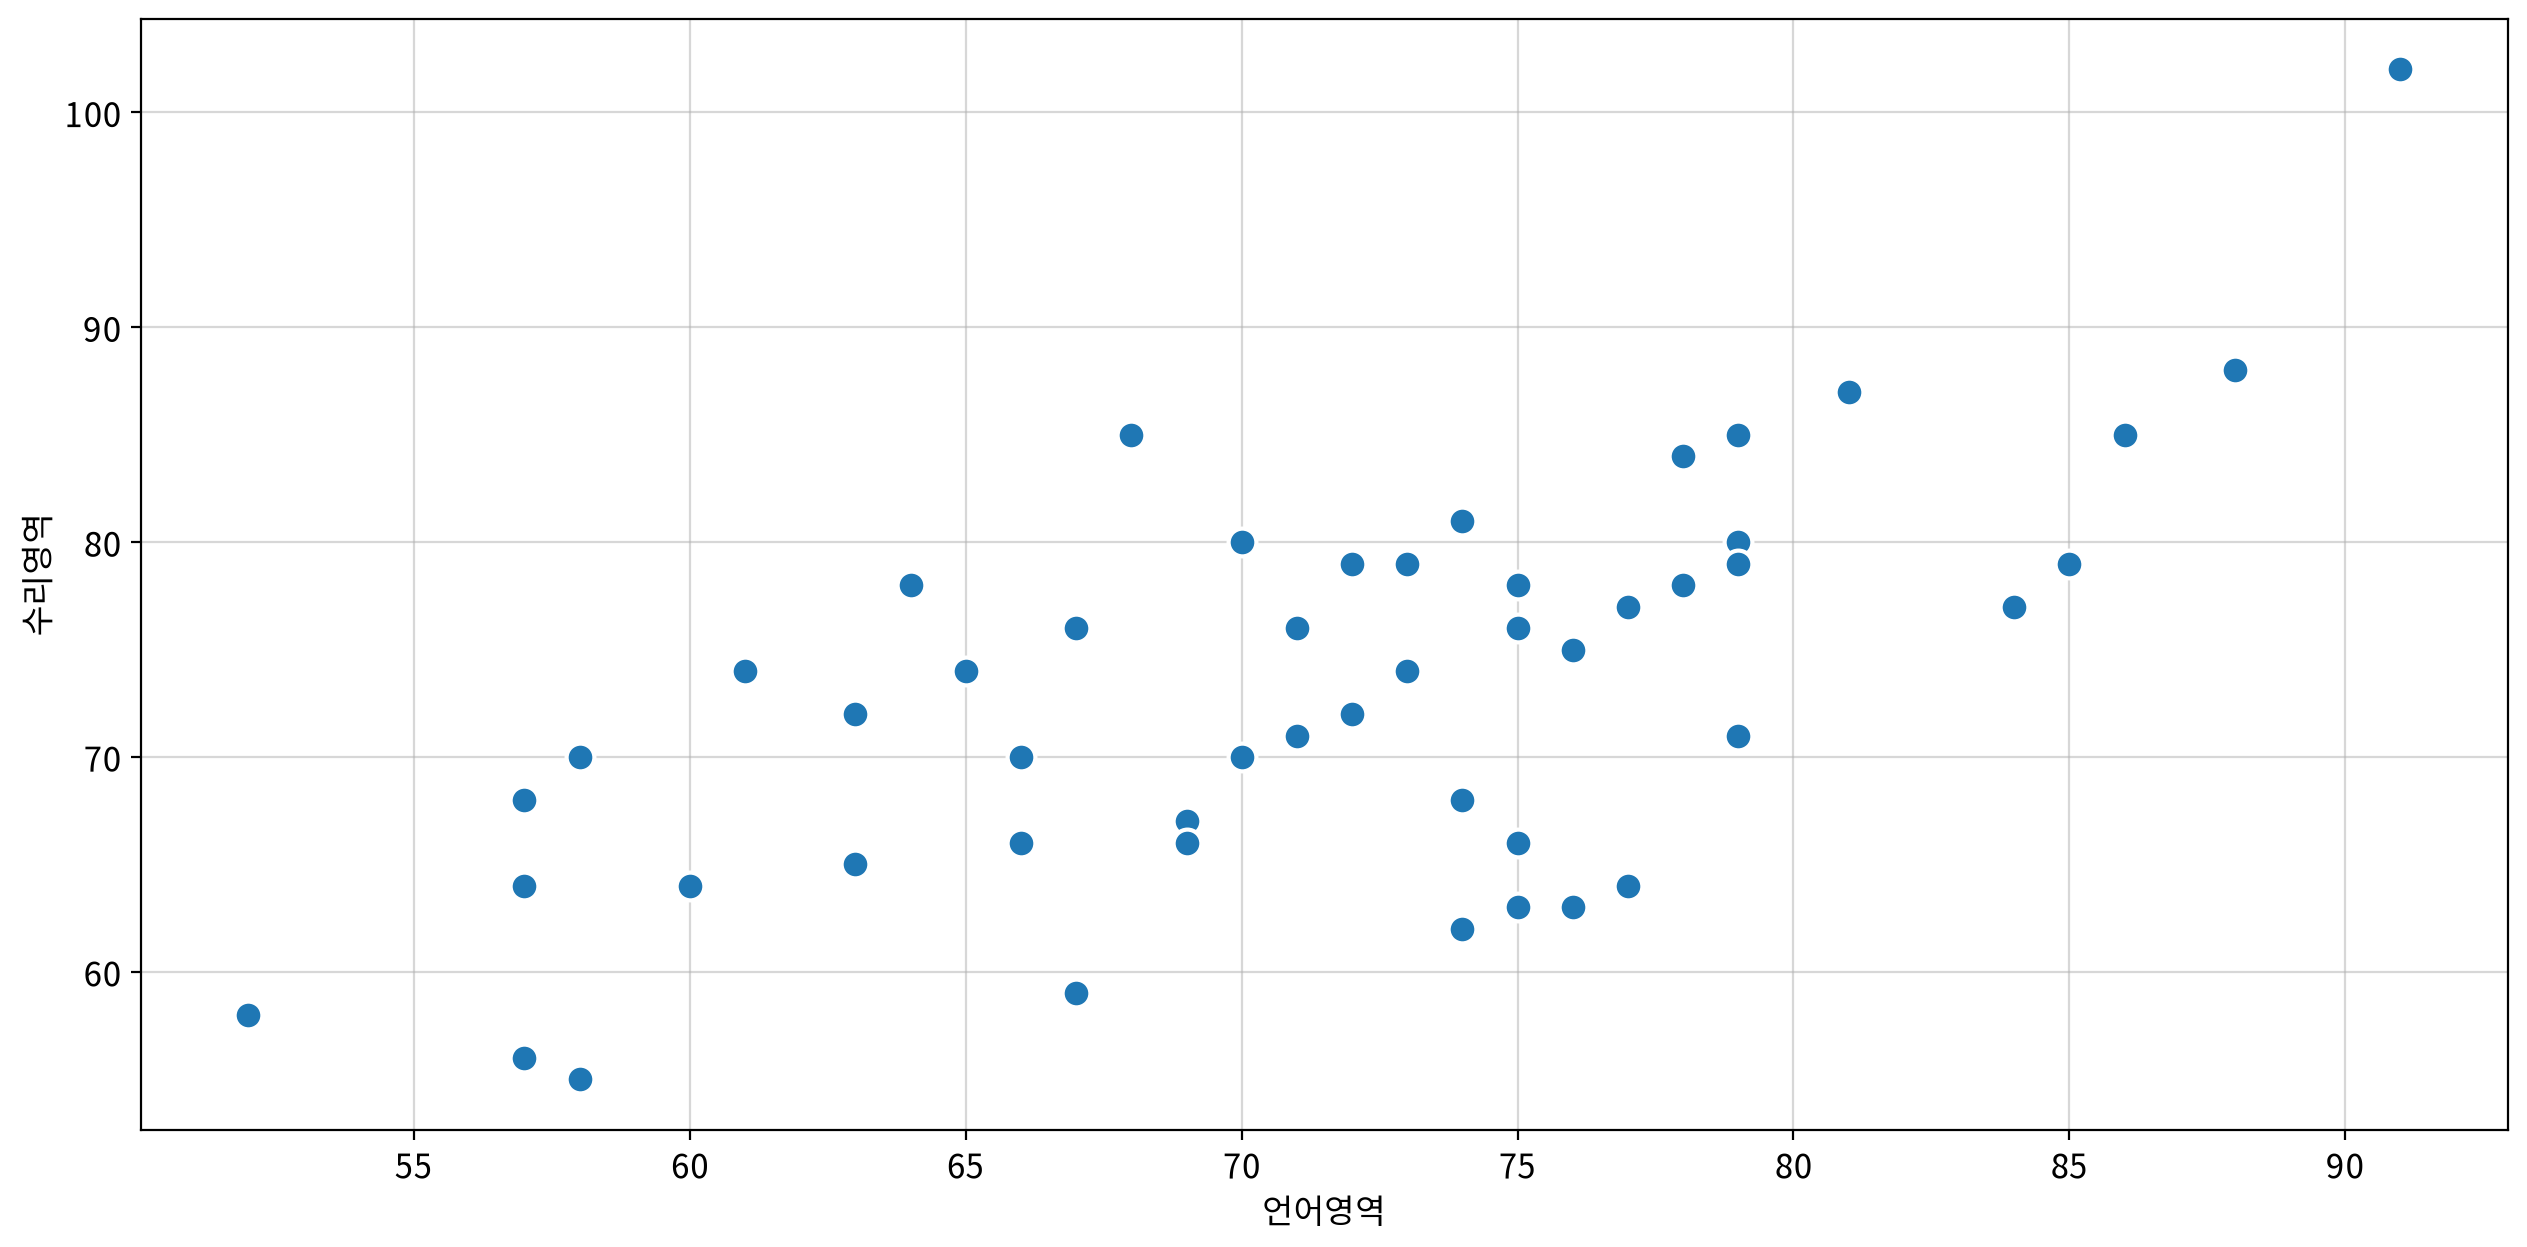

In [4]:
my_plot.scatterplot(origin, x="언어영역", y="수리영역")

### 3. 선형성의 통계적 검정 (Ramsey RESET Test)

In [5]:
x = origin['언어영역']
y = origin['수리영역']

X = sm.add_constant(x) # 상수항 추가 ( 선형회귀에서 자세히 다룸 )
model = sm.OLS(y, X).fit()
reset = linear_reset(model, power=2, use_f=True) 

print(f"Ramsey RESET Test: {reset.pvalue:.4f}")

Ramsey RESET Test: 0.1884


### 4. 이상치 점검 

In [6]:
results = {} 

for col in ['언어영역', '수리영역']: 
    # 특정 변수만 결측치를 제거하고 추출 
    temp = origin[col].dropna()

    # 사분위수 기반 이상치 개수 계산 
    q1 = temp.quantile(0.25)
    q3 = temp.quantile(0.75)
    iqr = q3 - q1 
    out_iqr = int(np.sum((temp < q1-1.5*iqr) | (temp > q3 + 1.5*iqr)))

    results[col] = {
        # 왜도 (분포의 비대칭성)
        'skew' : temp.skew(), 
        # 사분위수 (IQR) 기반 이상치 개수 
        'outliers(IQR)' : out_iqr
    }

result_df = DataFrame(results).T
result_df

,skew,outliers(IQR)
언어영역,-0.103,0.000
수리영역,0.367,1.000


### 5. 이상치에 따른 상관계수 변화 확인 

In [7]:
# 두 변수를 함께 결측 제거한 원본 데이터 
df_full = origin[["언어영역", "수리영역"]].dropna()

# IQR(사분위수) 울타리를 벗어나지 않은 행만 남겨 이상치 제거 데이터 프레임을 별도로 생성 
df_trim = df_full.copy()

for col in ["언어영역", "수리영역"]: 
    # 울타리는 항상 원본(df_full) 기준으로 계산 
    q1 = df_full[col].quantile(0.25)
    q3 = df_full[col].quantile(0.75)
    iqr = q3-q1 
    df_trim = df_trim[(df_trim[col] >= q1-1.5*iqr) & 
                      (df_trim[col] <= q3+1.5*iqr)]
    
# 원본과 이상치 제거 데이터에 대한 피어슨 상관계수 계산 
r_full = pearsonr(df_full["언어영역"], df_full["수리영역"])[0]
r_trim = pearsonr(df_trim["언어영역"], df_trim["수리영역"])[0]

print(f"피어슨 r (전체) : {r_full:.3f} (n={len(df_full)})")
print(f"피어슨 r (이상치 제외) : {r_trim:.3f} (n={len(df_trim)})")
print(f"변화량 : {abs(r_full - r_trim) : .3f}")


피어슨 r (전체) : 0.671 (n=50)
피어슨 r (이상치 제외) : 0.622 (n=49)
변화량 :  0.049


### 6. 이상치 영향 판정 

In [8]:
# 왜도가 크다 (|skew| > 1) 
skew_flag = bool((result_df['skew'].abs() > 1).any())

# 이상치가 상관계수를 크게 바꾼다. 
influential_flag = bool(abs(r_full - r_trim) >= 0.1)

print(f"이상치 영향: {influential_flag or skew_flag}")

이상치 영향: False


## #03. 모듈화 기능 확인 

### 1. 가정 확인 -> 상관 분석 자동화 

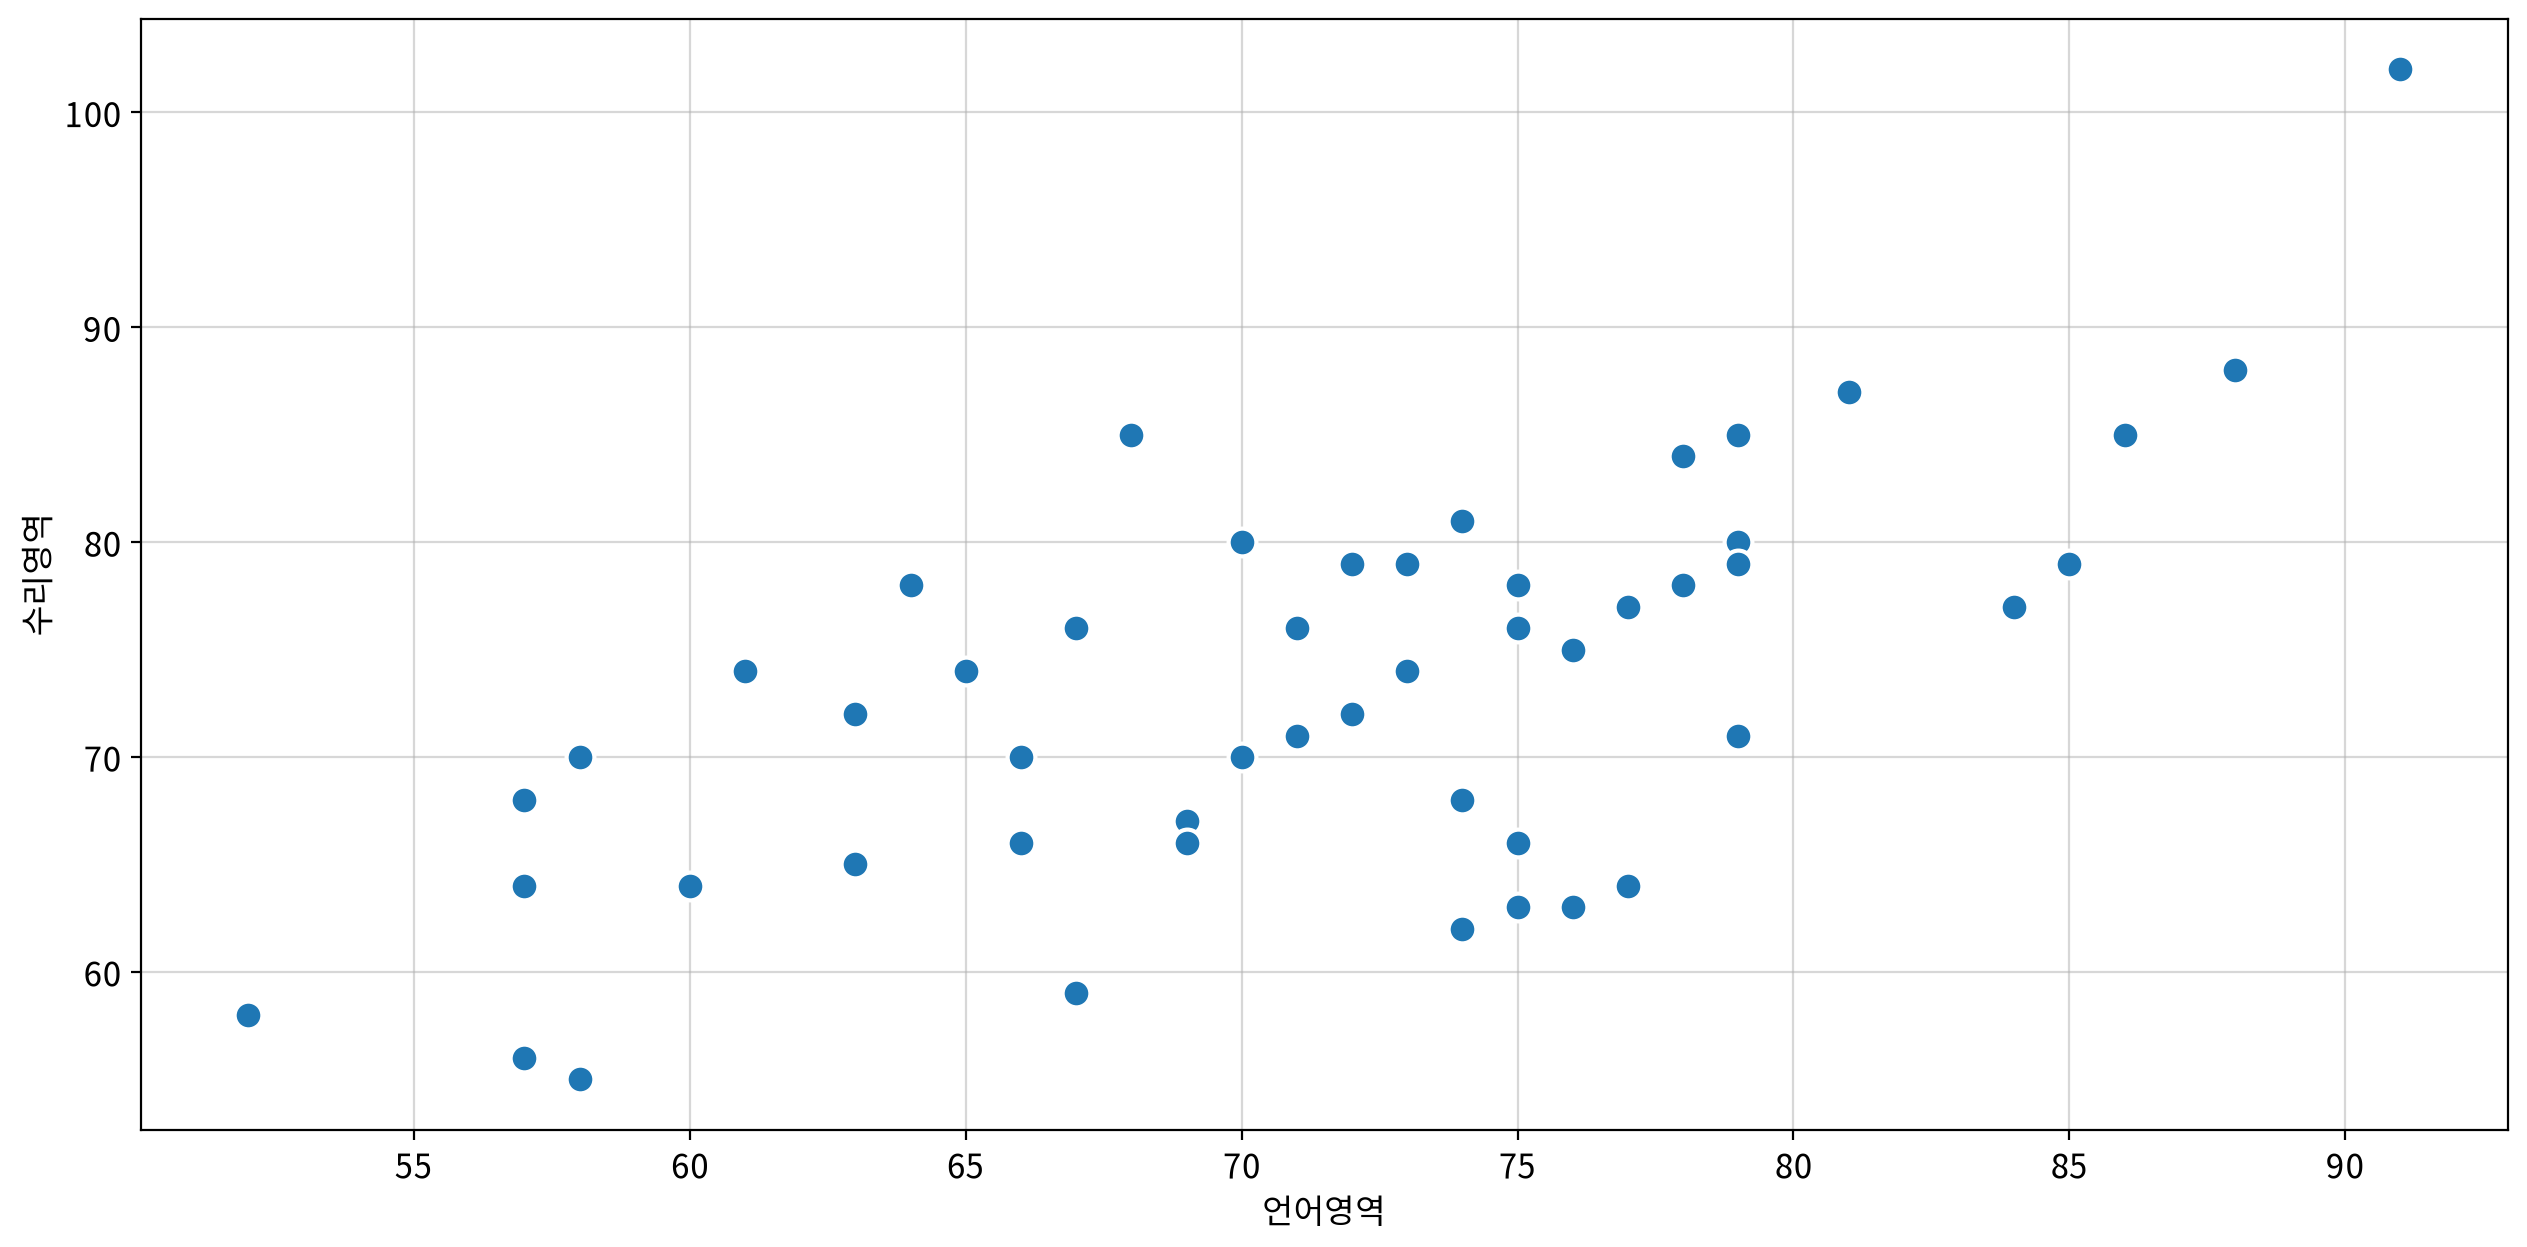

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
언어영역,수리영역,Pearson,0.671,0.000,Moderate,True,True,True,False,False


In [9]:
my_stats.correlation(origin, "언어영역", "수리영역")

## #01. 연습문제 

In [10]:
origin = load_data('baseball')
origin.head()

📚 야구팀의 홈런수와 타율에 관한 자료 (출처: 방송통신대학교 통계학 개론)


,홈런수,평균타율
0,174,0.277
1,163,0.276
2,161,0.272
3,230,0.272
4,214,0.269


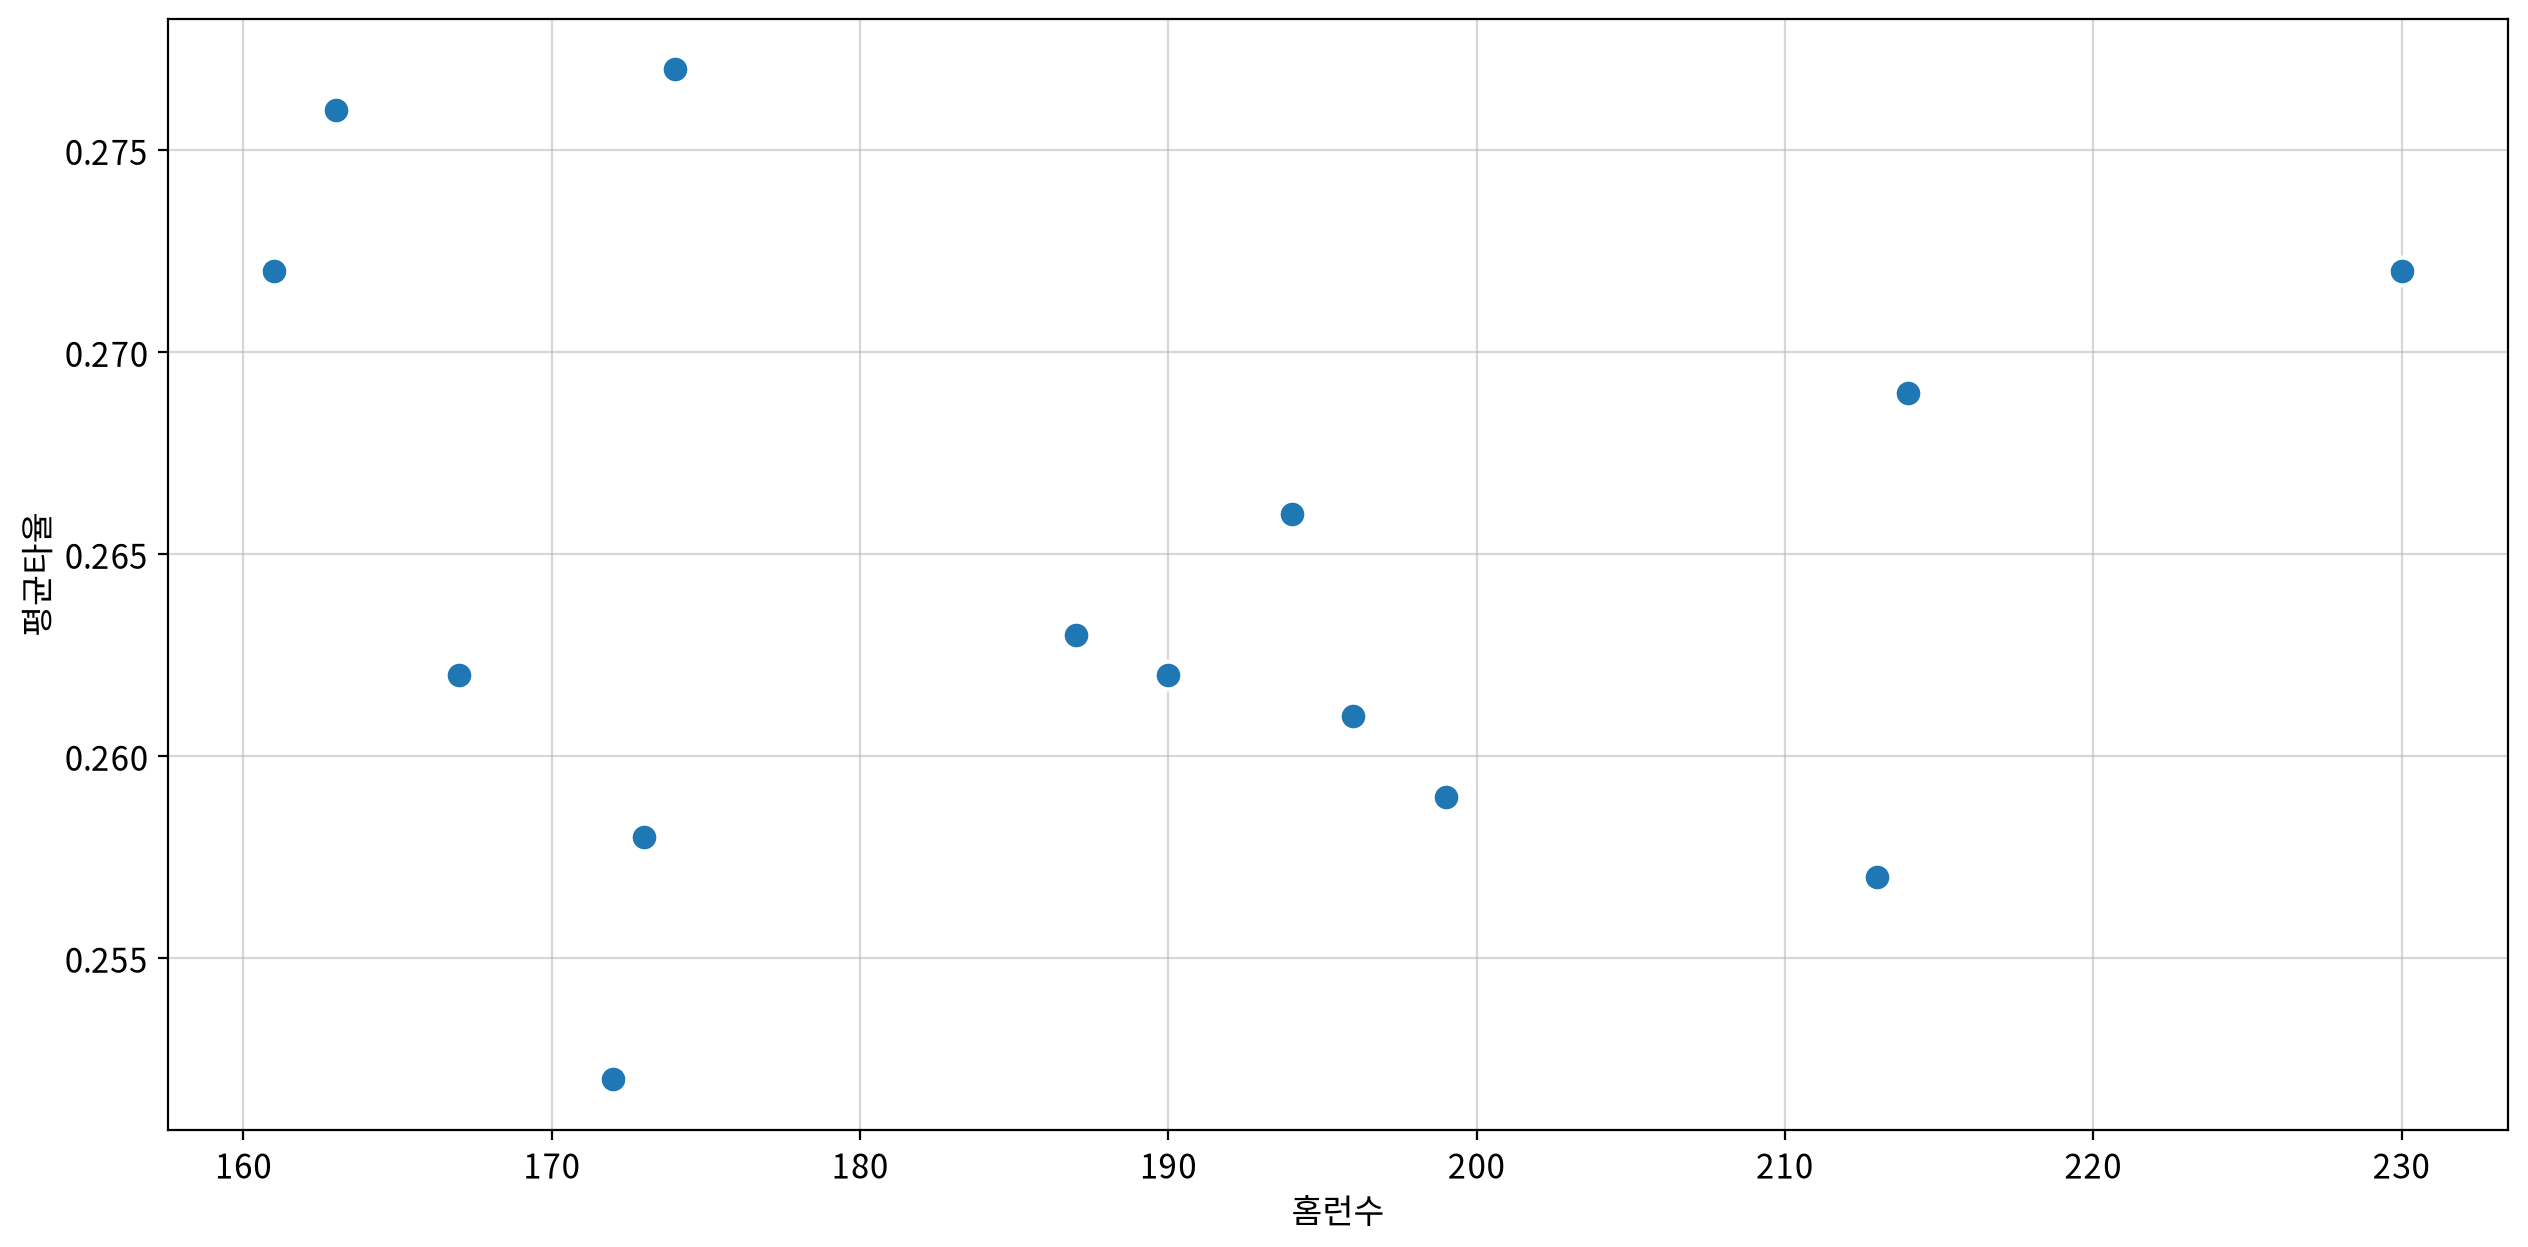

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
홈런수,평균타율,Pearson,-0.075,0.800,Weak,True,True,True,False,False


In [11]:
my_stats.correlation(origin, "홈런수", "평균타율")

## #02. 연습문제 

In [12]:
origin = load_data('product')
origin.head()

📚 어떤 원료의 품질특성(x)과 이 원료를 사용하여 만든 제품의 특성(y)에 관한 조사결과 (출처: 방송통신대학교 통계학 개론)


,x,y
0,36,29
1,40,32
2,34,29
3,44,40
4,33,31


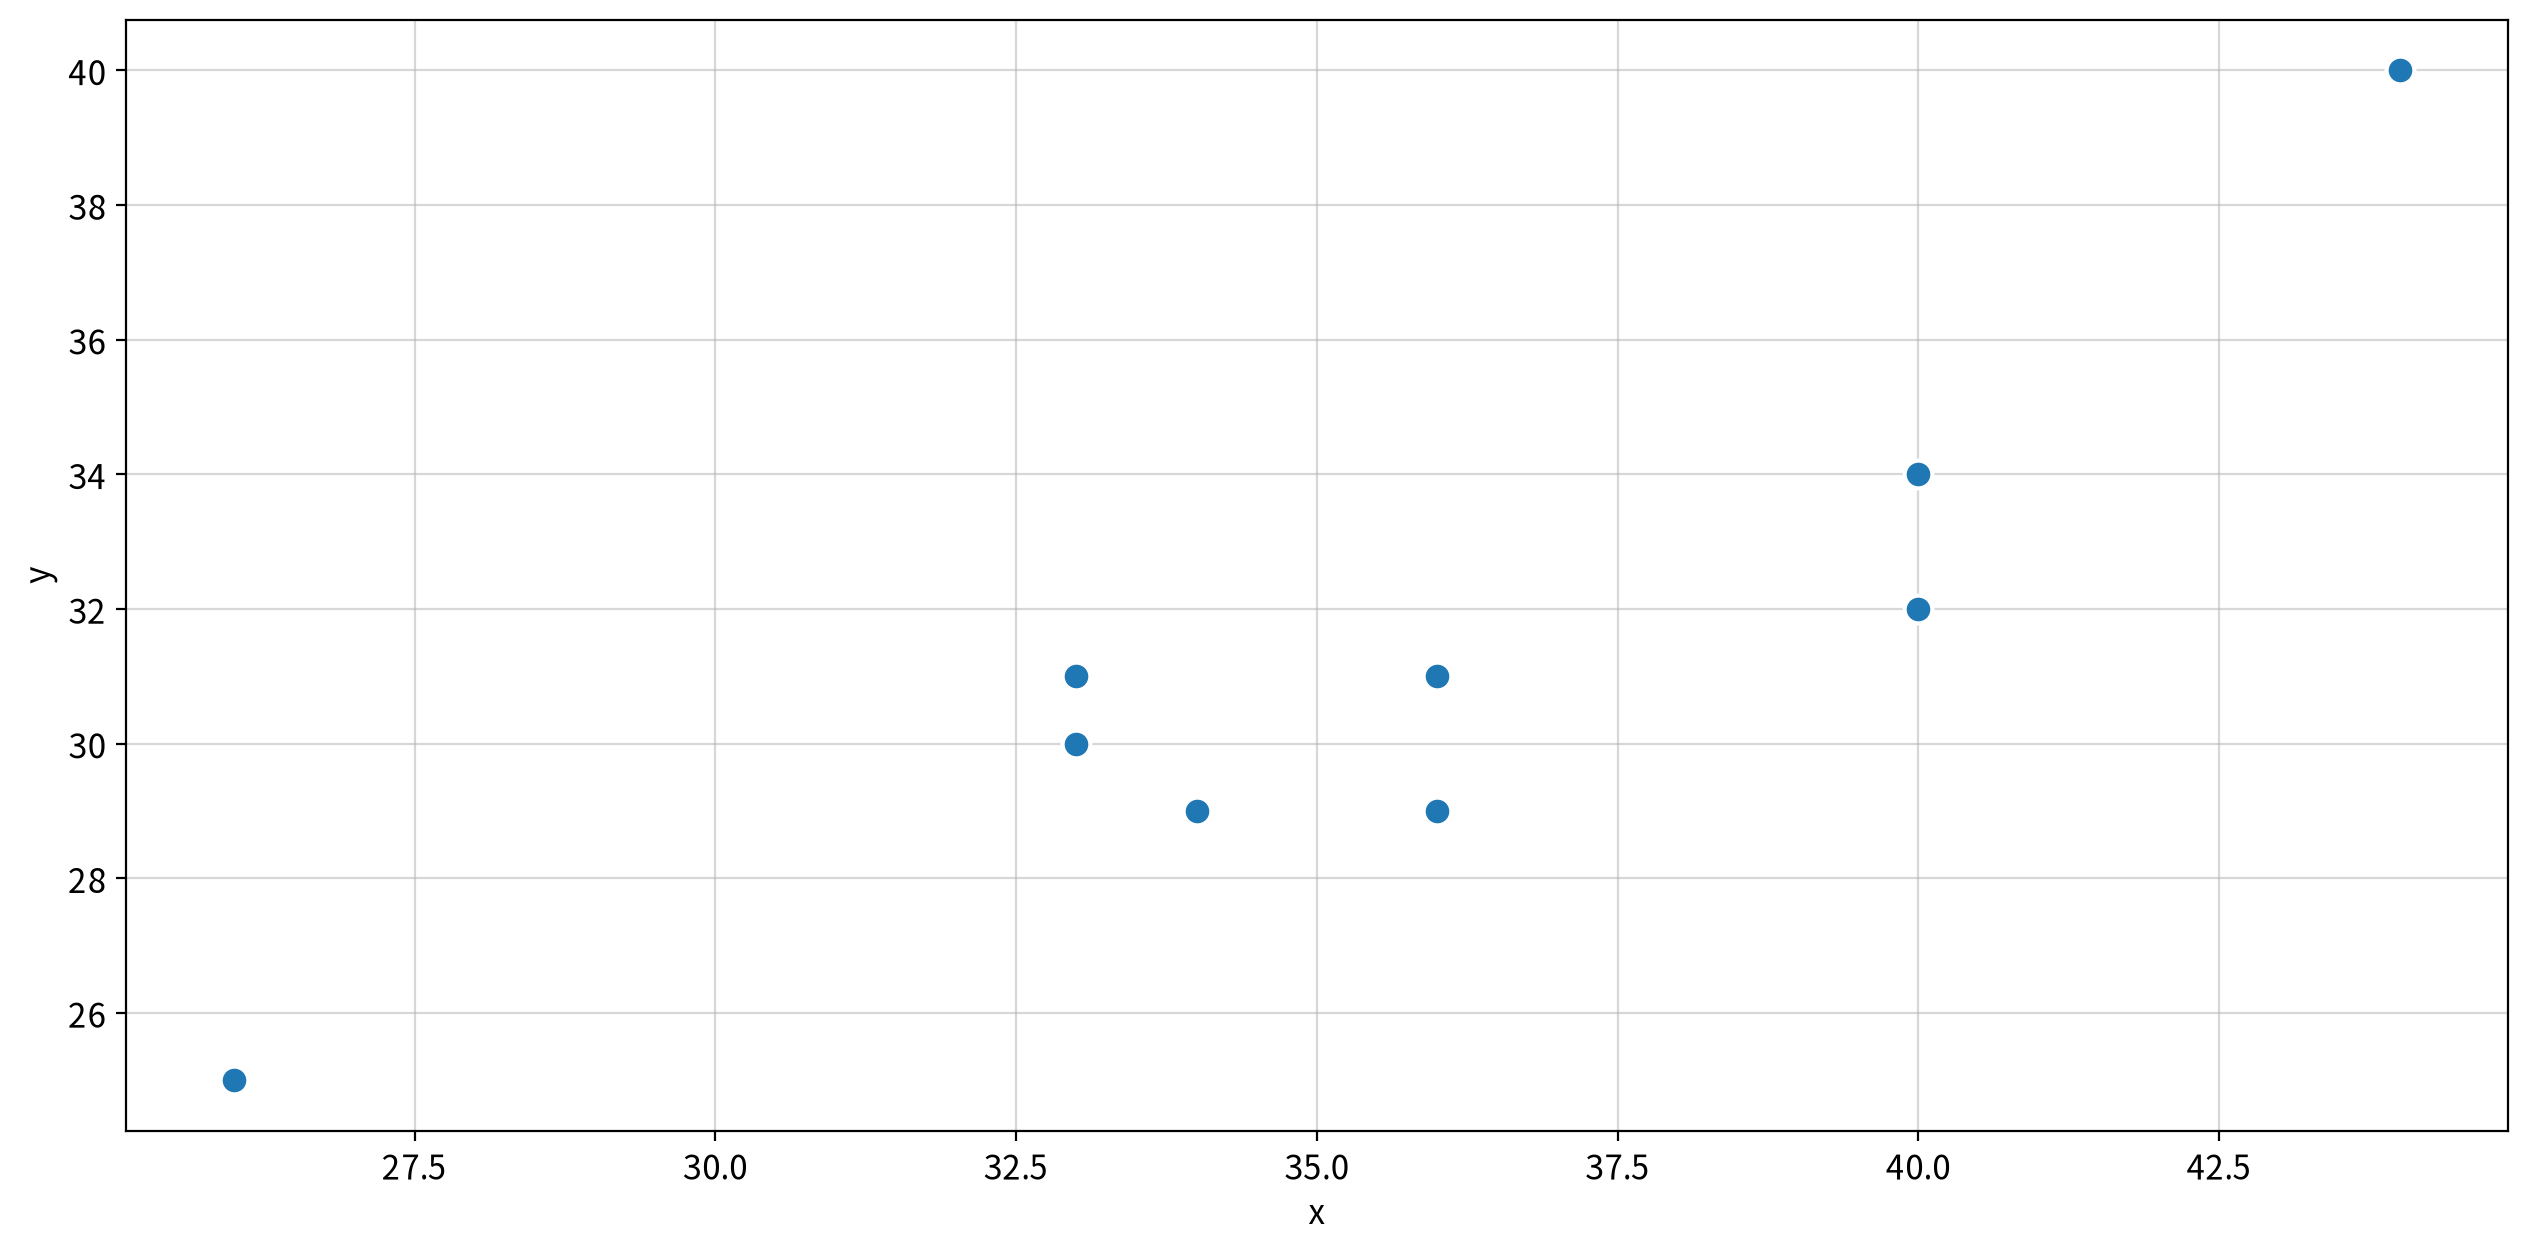

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
x,y,Spearman,0.737,0.015,Strong,True,False,True,False,True


In [13]:
my_stats.correlation(origin, "x", "y")

## #03. 연습문제 

In [14]:
origin = load_data('study_time')
origin.head()

📚 학생들에 대한 공부 시간과 성적 데이터 (출처: 방송통신대학교 통계학 개론)


,공부시간,성적
0,2,65
1,4,85
2,3,75
3,5,90
4,6,95


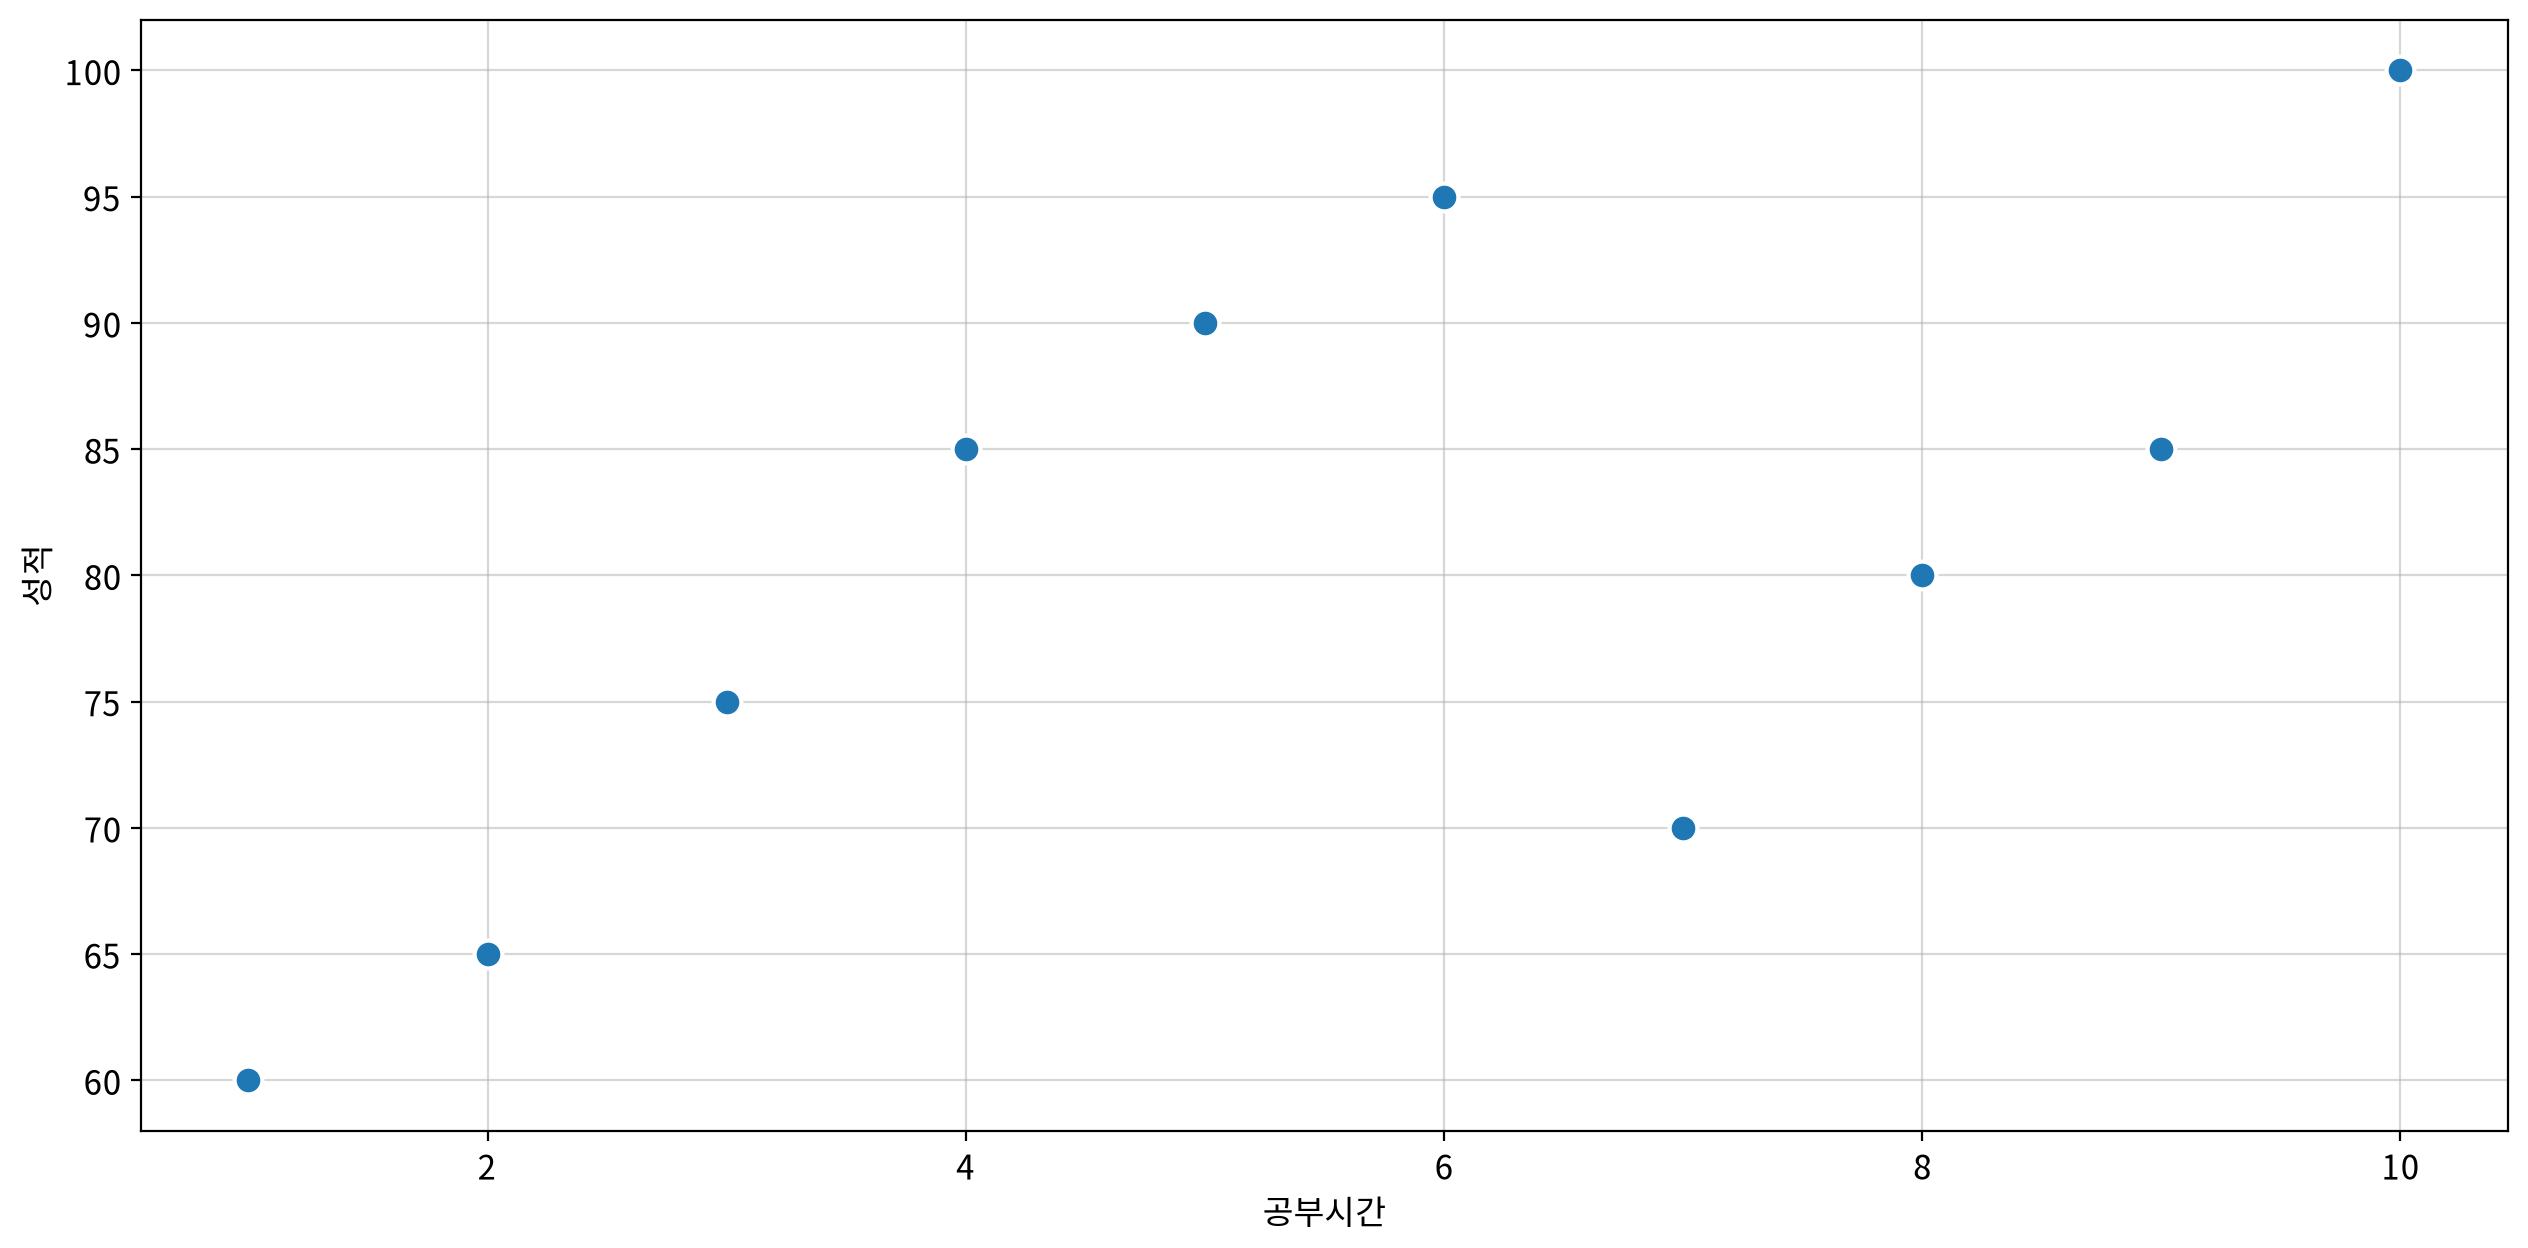

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
공부시간,성적,Pearson,0.684,0.029,Moderate,True,True,True,False,False


In [15]:
my_stats.correlation(origin, "공부시간", "성적")